8(b) Compare the performance of a custom CNN vs a pre-trained CNN on the CIFAR-10 dataset.

In [1]:
!pip install torch torchvision matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Preprocessing and Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')


100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


In [3]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [4]:
from torchvision import models

# Load pre-trained ResNet18
pretrained_model = models.resnet18(pretrained=True)

# Modify the final layer for 10 classes (CIFAR-10)
pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, 10)

# Move model to device
pretrained_model = pretrained_model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


In [5]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


In [6]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


In [7]:
# Initialize the custom CNN model
custom_cnn = CustomCNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_custom = optim.Adam(custom_cnn.parameters(), lr=0.001)

# Train the custom CNN model
train_model(custom_cnn, train_loader, criterion, optimizer_custom, num_epochs=10)


Epoch [1/10], Loss: 1.4612
Epoch [2/10], Loss: 1.0494
Epoch [3/10], Loss: 0.8648
Epoch [4/10], Loss: 0.7453
Epoch [5/10], Loss: 0.6516
Epoch [6/10], Loss: 0.5759
Epoch [7/10], Loss: 0.5136
Epoch [8/10], Loss: 0.4535
Epoch [9/10], Loss: 0.4009
Epoch [10/10], Loss: 0.3532


In [8]:
# Define optimizer for the pre-trained model
optimizer_resnet = optim.Adam(pretrained_model.parameters(), lr=0.001)

# Train the pre-trained ResNet18 model
train_model(pretrained_model, train_loader, criterion, optimizer_resnet, num_epochs=10)


Epoch [1/10], Loss: 0.9617
Epoch [2/10], Loss: 0.6577
Epoch [3/10], Loss: 0.5287
Epoch [4/10], Loss: 0.4331
Epoch [5/10], Loss: 0.3518
Epoch [6/10], Loss: 0.2644
Epoch [7/10], Loss: 0.2163
Epoch [8/10], Loss: 0.1860
Epoch [9/10], Loss: 0.1399
Epoch [10/10], Loss: 0.1455


In [9]:
# Evaluate the custom CNN model
custom_cnn_accuracy = evaluate_model(custom_cnn, test_loader)
print(f"Custom CNN Accuracy: {custom_cnn_accuracy:.2f}%")

# Evaluate the pre-trained ResNet18 model
pretrained_accuracy = evaluate_model(pretrained_model, test_loader)
print(f"Pre-trained ResNet18 Accuracy: {pretrained_accuracy:.2f}%")


Custom CNN Accuracy: 76.57%
Pre-trained ResNet18 Accuracy: 80.13%


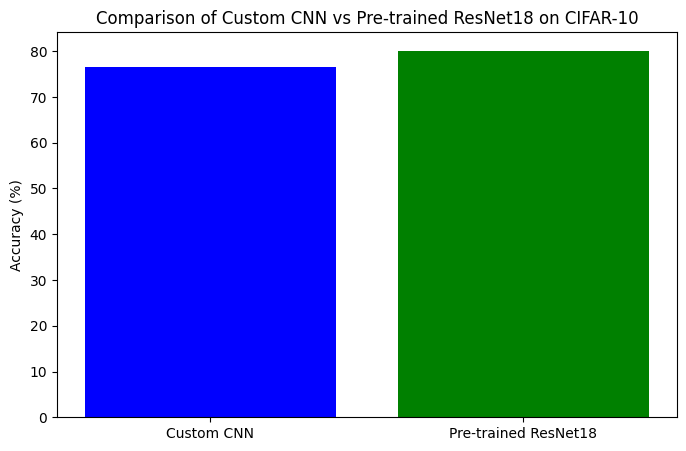

In [10]:
# Plotting the performance comparison
plt.figure(figsize=(8, 5))
models = ['Custom CNN', 'Pre-trained ResNet18']
accuracies = [custom_cnn_accuracy, pretrained_accuracy]

plt.bar(models, accuracies, color=['blue', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Custom CNN vs Pre-trained ResNet18 on CIFAR-10')
plt.show()
